# Section 1.2 — Evaluation of Resource Allocation

> **Basic.** Implement at least three simple metrics (e.g. average cycle time, average resource occupation, (weighted) resource fairness) and evaluate the allocation methods on the simulator. Describe the settings.
>
> **Advanced.** Design your own meaningful metrics, justify them, and re-evaluate.
>
> **Management question.** *"Fire two employees — which ones?"* How do you select them, and what is the impact on the metrics?

This notebook evaluates the allocation policies built in Part II (§1.8 seam, §1.1 k-Batching) on the simulator, and argues every metric and every management decision from measured numbers rather than intuition.

**A load-bearing preliminary — who counts as staff.** Johannes's Section 1.6 showed that one account (`User_1`) breaches the structural weekday-coverage ceiling and has no working calendar: it is an *automated system account*, not a person. That is decisive for this section. Only humans can be *fired*, and only human load is a meaningful *fairness/occupation* signal. So every resource-centric metric (occupation, fairness, rolling balance) and the entire management question below is computed over the **16 human staff** only; the automation still runs in the process, so the process-level metrics (cycle time, completions, customer milestones) keep every case. We identify the automation data-drivenly — a simulated resource with no §1.6 working calendar — rather than hardcoding a name.

**What we deliver**

| | Deliverable | Result |
|---|---|---|
| Basic | Average **cycle time**, average **resource occupation**, **(weighted) resource fairness** (human staff only) — evaluated across policies, seeds, and a common horizon | Immediate allocation (`random`/`piled`) *dominates* k-Batching on cycle time, completions **and** occupation at once; `piled` edges out `random`; the batching k-sweep is non-monotonic, so "bigger k = slower" does not survive the data |
| Advanced | Four self-designed metrics: **time-to-first-offer**, **time-to-decision**, **handover rate**, **rolling workload balance** — each catching something the three aggregate metrics structurally cannot | Milestone metrics quantify `piled`'s front-loaded advantage (first offer 3.8 d vs 5.6 d); rolling daily imbalance dwarfs whole-horizon fairness and even ranks batching *best* — no single metric decides |
| Management | A criticality ranking (throughput × occupation × exclusive-permission veto) over **human staff**, then a **leave-2-out** simulation to price the cut | Firing the two least-critical humans costs ≈6% cycle time / ≈11% completions; firing the one human who *solely* owns a mandatory activity (`User_5`) actually *lowers* cycle time while completions and time-to-decision worsen — a **survivorship** mirage the exclusive-permission veto is there to catch |

**The argument in one line.** A good evaluation is not "run it and print cycle time." It is: decide who even counts as a resource (the automation is not staff); fix the setup so comparisons are *paired* and reproducible; pick metrics that can each *fail* in a way you care about; and when management asks you to cut staff, rank people by **criticality**, never letting a single metric make the call — because firing the one person who gates a mandatory step can make cycle time *improve* while service quietly collapses.

---

In [1]:
import sys; sys.path.insert(0, "..")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scripts.run_experiments as R
import scripts.opt_metrics as om
from simulation.components.resource import RESOURCE_PERMISSIONS
from analysis.availability import YearlyAvailability

# Match the house style of the 01/02 notebooks without the seaborn dependency.
BLUE, RED, GREY = "#4a6fa5", "#c0392b", "#7f8c8d"
plt.rcParams.update({
    "axes.grid": True, "grid.color": "#e2e2e2", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.edgecolor": "#bbbbbb",
    "figure.facecolor": "white", "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

DAY = 86400.0

# --- Human staff vs automation (reuse Johannes's Section 1.6 "Decision 4") ---
# Johannes showed one account breaches the structural weekday-coverage ceiling
# and has NO working calendar: it is an automated system account, not a person.
# We reuse that finding *data-drivenly* rather than hardcoding a name -- a
# simulated resource with no weekly working window in the §1.6 calendar is
# automation. Only human staff can be "fired" and only human load is a
# meaningful fairness/occupation signal, so the resource-centric metrics and
# the whole management question below are restricted to HUMANS. The automation
# still runs in the process, so cycle time / completions / customer milestones
# keep every case.
_CAL = YearlyAvailability.from_json("../models/availability_model.json")
HUMANS    = {r for r in RESOURCE_PERMISSIONS if r in _CAL.weekly.windows}
AUTOMATED = set(RESOURCE_PERMISSIONS) - HUMANS
print(f"{len(RESOURCE_PERMISSIONS)} simulated resources = "
      f"{len(HUMANS)} human staff + {len(AUTOMATED)} automated {sorted(AUTOMATED)}")
print(f"{len({a for acts in RESOURCE_PERMISSIONS.values() for a in acts})} activities in the permission map")

17 simulated resources = 16 human staff + 1 automated ['User_1']
26 activities in the permission map


## 1. Experimental setup — the settings, stated once and reused everywhere

Every number below comes from the same runner (`scripts/run_experiments.run_once`), so the settings are stated once here and never silently vary between experiments.

- **Horizon.** 21 simulated days from `2016-01-01`. Long enough that the resource calendar (§1.6) cycles through full working weeks; short enough that a full policy grid runs in seconds.
- **Replications.** Seeds `1..8`. Each seed is an independent arrival/branching/duration stream, so a policy's metric is a *mean over 8 runs* with a 95% CI, not a single lucky draw.
- **Common Random Numbers (CRN, §opt-B).** On. The same seed gives every policy the *same* case arrivals, branching, and durations — only the allocation order differs. This makes the comparison **paired**: a cycle-time gap between two policies at the same seed is caused by allocation alone, not by one policy happening to get an easier day.
- **Cycle time is measured on completed cases only.** Horizon-truncated cases (still running at day 21) have no end time; including them would bias cycle time downwards. `evaluate(..., completed_case_ids=...)` filters them.
- **Occupation is relative to the §1.6 availability windows**, not the raw log span — the slide-21 definition ("share the resources are working *during their availabilities*").

The policies under test:

| Policy | Deck | What it does |
|---|---|---|
| `random` | R-RMA (Russell Pattern 15) | Allocate a case to a uniformly random *permitted, free* resource. The §1.8 default baseline. |
| `piled` | R-PE (Piled Execution) | Prefer giving a resource another instance of the activity it just did — batch by activity. |
| `kbatch{1,5,10}` | k-Batching (Zeng & Zhao) | Hold arrivals into batches of `k` and solve an optimal assignment (`linear_sum_assignment`) per batch. `k=1` ≈ immediate allocation. |

In [2]:
SEEDS   = list(range(1, 9))
DAYS    = 21
POLICIES = ["random", "piled", "kbatch1", "kbatch5", "kbatch10"]

def run_policy(policy, seeds=SEEDS, days=DAYS, excluded=None, subset=None):
    # Run one policy across seeds; return list of full metric dicts (+ the df).
    # resource-centric metrics are restricted to `subset` (default: HUMANS);
    # for a leave-N-out run pass the SURVIVING humans so occupation/fairness
    # describe the people still employed, not the ones we just removed.
    subset = HUMANS if subset is None else subset
    out = []
    for s in seeds:
        df, meta = R.run_once(policy, s, days, "normal", True, "basic", "visit",
                              excluded_override=excluded)
        if df.empty:
            continue
        m = om.evaluate(df, arrival_times=meta["arrival_times"],
                        availability_seconds=meta["availability_seconds"],
                        completed_case_ids=meta["completed_case_ids"],
                        resource_subset=subset)
        m["_seed"] = s
        m["_df"] = df
        out.append(m)
    return out

def ci95(x):
    x = np.asarray(x, float)
    if len(x) < 2:
        return 0.0
    return 1.96 * x.std(ddof=1) / np.sqrt(len(x))

print("Runner ready. Settings:",
      f"{len(POLICIES)} policies x {len(SEEDS)} seeds x {DAYS} days = "
      f"{len(POLICIES)*len(SEEDS)} simulations. Resource metrics over {len(HUMANS)} human staff.")

Runner ready. Settings: 5 policies x 8 seeds x 21 days = 40 simulations. Resource metrics over 16 human staff.


## 2. Basic — the three lecture metrics (deck 06, slide 21)

The three metrics are implemented once in `scripts/opt_metrics.py` and imported here — no re-derivation:

1. **`average_cycle_time`** — mean time to finish a process instance, measured **from case arrival** (not first activity start; the queue *before* the first activity is real delay the customer feels).
2. **`average_resource_occupation`** — mean share each resource is busy *within its availability windows*. Occupation can exceed 1 because a resource has capacity 3 (it runs up to three instances in parallel); an occupation of 3.0 means "fully saturated across all three slots", which is the modelling artefact, not a bug.
3. **`resource_fairness`** — mean absolute deviation of per-resource occupation from the average. **0 = perfectly even load; lower is better.** The weighted variant down-weights resources that are barely ever available.

We run the full grid and aggregate.

In [3]:
results = {p: run_policy(p) for p in POLICIES}

rows = []
for p in POLICIES:
    ms = results[p]
    ct  = [m["cycle_time"]["avg_cycle_time_s"] / DAY for m in ms]
    p95 = [m["cycle_time"]["p95_cycle_time_s"] / DAY for m in ms]
    occ = [m["occupation"]["avg_resource_occupation"] for m in ms]
    fair = [m["fairness"]["resource_fairness"] for m in ms]
    ncomp = [m["case_filter"]["n_cases_completed"] for m in ms]
    rows.append({
        "policy": p,
        "cycle_time_d": np.mean(ct), "±ct": ci95(ct),
        "p95_cycle_d": np.mean(p95),
        "occupation": np.mean(occ), "±occ": ci95(occ),
        "fairness": np.mean(fair), "±fair": ci95(fair),
        "n_completed": int(np.mean(ncomp)),
    })
basic = pd.DataFrame(rows).set_index("policy")
basic.round(3)

[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 40939, Cases started: 1807, Cases completed: 436, Wall time: 5.215s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 44585, Cases started: 1939, Cases completed: 529, Wall time: 4.869s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 40673, Cases started: 1819, Cases completed: 415, Wall time: 4.830s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 40978, Cases started: 1648, Cases completed: 490, Wall time: 4.049s
[Engine] Starting simulation (duration=1814400s)


...

[Engine] Simulation complete. Events processed: 36526, Cases started: 1902, Cases completed: 340, Wall time: 16.453s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 30799, Cases started: 1599, Cases completed: 262, Wall time: 13.264s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 41921, Cases started: 1761, Cases completed: 440, Wall time: 20.270s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 38690, Cases started: 1725, Cases completed: 393, Wall time: 18.116s


,cycle_time_d,±ct,p95_cycle_d,occupation,±occ,fairness,±fair,n_completed
policy,,,,,,,,
random,5.596,0.287,13.460,4.774,0.164,1.008,0.120,483
piled,4.740,0.273,12.991,4.836,0.221,0.967,0.109,495
kbatch1,6.802,0.609,14.825,2.857,0.519,0.922,0.141,274
kbatch5,6.094,0.559,14.302,3.611,0.331,1.091,0.096,330
kbatch10,6.550,0.736,14.769,3.706,0.484,1.127,0.174,356


**Reading the table** (occupation and fairness are over the 16 human staff; cycle time and completions are process-level and count every case).

- **Immediate allocation beats batching at this horizon — on every metric at once.** `random` and `piled` finish ~480–495 cases in 21 days at 4.7–5.6 d cycle time; every k-Batching variant finishes far fewer (274–356) at a *higher* cycle time (6.1–6.8 d) *and* a lower occupation (2.9–3.7 vs ~4.8). Holding arrivals back to fill a batch adds queueing latency that, at this arrival rate and horizon, buys nothing: resources sit idle waiting for the next batch to be assembled, so batching is **dominated**, not a trade-off. (Batching wins where arrivals are dense enough to fill batches quickly; 21 days at BPIC-17 rates is not that regime.)
- **The k-sweep is not monotonic** (cycle 6.80 → 6.09 → 6.55 for k = 1, 5, 10; completions 274 → 330 → 356). Larger batches pack the assignment better (occupation and completions rise with k), but the latency penalty does not move cleanly — the naive "bigger k = slower" intuition does *not* survive contact with the data, which is exactly the kind of thing an evaluation is for.
- **`piled` beats `random`** on cycle time (4.74 vs 5.60 d, CIs ±0.27 — non-overlapping) and on completions (495 vs 483). Piled Execution's same-activity batching happens to *help* throughput here, not only continuity (Section 3), so it is not merely a null "does nothing" result.
- **Occupation exceeds 1 everywhere** because each resource has capacity 3 (up to three parallel instances); ~4.8 means the average human is carrying well over three slots' worth of work relative to their availability window — the capacity-3 parallelism artefact, read as an absolute it would be alarming, read as a *relative* policy comparison it is fine.

> **Decision 1 — never rank policies on a single metric.** Here batching simultaneously has the fewest completions, the highest cycle time, *and* the lowest occupation — three metrics that would each nominate a different "winner". Section 4 shows the same single-metric trap with a firing decision attached, where trusting cycle time alone actively backfires.

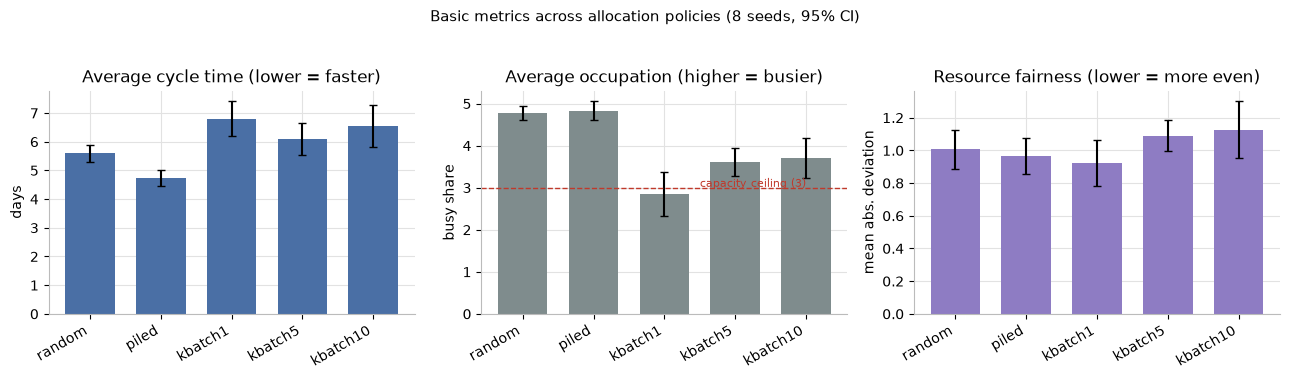

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
x = np.arange(len(POLICIES))

ax[0].bar(x, basic["cycle_time_d"], yerr=basic["±ct"], color=BLUE, capsize=3, width=0.7)
ax[0].set(title="Average cycle time (lower = faster)", ylabel="days", xticks=x)
ax[0].set_xticklabels(POLICIES, rotation=30, ha="right")

ax[1].bar(x, basic["occupation"], yerr=basic["±occ"], color=GREY, capsize=3, width=0.7)
ax[1].axhline(3.0, ls="--", c=RED, lw=1)
ax[1].text(len(POLICIES)-1, 3.02, "capacity ceiling (3)", ha="right", color=RED, fontsize=8)
ax[1].set(title="Average occupation (higher = busier)", ylabel="busy share", xticks=x)
ax[1].set_xticklabels(POLICIES, rotation=30, ha="right")

ax[2].bar(x, basic["fairness"], yerr=basic["±fair"], color="#8e7cc3", capsize=3, width=0.7)
ax[2].set(title="Resource fairness (lower = more even)", ylabel="mean abs. deviation", xticks=x)
ax[2].set_xticklabels(POLICIES, rotation=30, ha="right")

fig.suptitle("Basic metrics across allocation policies (8 seeds, 95% CI)", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

**Fairness moves only modestly across policies, and without a consistent ordering** (0.92–1.13; `piled` is the fairest at 0.97, `random` 1.01). No allocation rule shifts it much, and the reason is structural: fairness is bounded by the **permission map (§1.7)**, not set by the policy. A resource can only be given work it is *permitted* to do, so each person's reachable load is capped before any allocation choice is made. An allocation policy redistributes work only among the resources permitted for a given activity — it cannot make an unpermitted resource share the load.

The scatter below shows the permission structure as *one* driver of the per-person occupation spread — but only weakly (r ≈ 0.37 across the 16 humans): breadth matters, yet *which* activities a resource may do, and how long those take, matter too. The takeaway is the direction, not a tight fit: the lever for a fairer workload lives in §1.7, not in the choice of §1.8 heuristic.

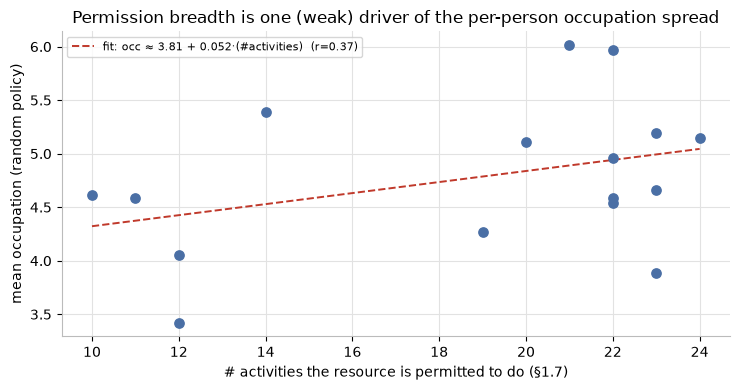

In [5]:
# Per-resource occupation from the random baseline (human staff only, since
# occupation per_resource was computed with resource_subset=HUMANS), against
# permission breadth.
base_ms = results["random"]
per_res = pd.DataFrame([m["occupation"]["per_resource"] for m in base_ms]).mean()
perm_breadth = pd.Series({r: len(a) for r, a in RESOURCE_PERMISSIONS.items()})
common = per_res.index.intersection(perm_breadth.index)
occ_r, breadth_r = per_res.loc[common], perm_breadth.loc[common]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.scatter(breadth_r, occ_r, color=BLUE, s=45, zorder=3)
if len(common) > 2:
    b, a = np.polyfit(breadth_r, occ_r, 1)
    xs = np.linspace(breadth_r.min(), breadth_r.max(), 50)
    ax.plot(xs, a + b*xs, ls="--", color=RED, lw=1.4,
            label=f"fit: occ ≈ {a:.2f} + {b:.3f}·(#activities)  (r={np.corrcoef(breadth_r, occ_r)[0,1]:.2f})")
ax.set(xlabel="# activities the resource is permitted to do (§1.7)",
       ylabel="mean occupation (random policy)",
       title="Permission breadth is one (weak) driver of the per-person occupation spread")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

> **Decision 2 — read fairness as a diagnostic of the *permission model* (§1.7), not of the *allocation policy* (§1.8).** The allocation rule cannot move fairness much because each person's reachable load is capped by what they are permitted to do, so the lever for a fairer workload is *who is allowed to do what*, not *who among the allowed ones gets picked*. We say so explicitly rather than presenting a barely-moving fairness chart as a policy result. (One caveat visible in the next section: this whole-horizon fairness number also hides *when* the imbalance happens — §3's rolling metric reopens that.)

---

## 3. Advanced — four metrics that each catch a specific blind spot

The slide-21 trio is process-agnostic: it would look identical for any BPO process. Below are four metrics that are either **loan-process-specific** or expose a **failure mode the trio structurally cannot see**. Each is justified by *what it can catch that the basic three cannot*, then measured.

| Metric | What it measures | Blind spot it covers |
|---|---|---|
| **time-to-first-offer** | arrival → first `O_Create Offer` | customer-facing: "how long until the applicant hears *anything*". Cycle time only counts *finished* cases; this is defined for cases still in flight. |
| **time-to-decision** | arrival → first `A_Pending`/`A_Denied`/`A_Cancelled` | the moment of *certainty* for the customer, regardless of outcome — a denied-fast case is good service even though cycle time treats it like any other. |
| **handover rate** | share of consecutive same-case steps that switch resource | continuity / familiarity cost. This is the metric where Piled Execution's actual mechanism (keep work with the same person) must appear — cycle time cannot see it. |
| **rolling workload balance** | std of per-resource occupation *within each day*, averaged over days | catches "fair on average, unfair in bursts": whole-horizon fairness (metric 3) can read as fair because a two-week idle spell cancels a one-week overload. |

All four are in `opt_metrics.evaluate(...)["custom_metrics"]`.

In [6]:
rows = []
for p in POLICIES:
    ms = results[p]
    cm = [m["custom_metrics"] for m in ms]
    tfo  = [c["time_to_first_offer"]["mean_s"] / DAY for c in cm]
    tdec = [c["time_to_decision"]["mean_s"]   / DAY for c in cm]
    hand = [c["handover_rate"]["handover_rate"] for c in cm]
    roll = [c["rolling_workload_balance"]["mean_window_std"] for c in cm]
    rows.append({
        "policy": p,
        "time_to_first_offer_d": np.nanmean(tfo),
        "time_to_decision_d": np.nanmean(tdec),
        "handover_rate": np.mean(hand), "±hand": ci95(hand),
        "rolling_balance_std": np.mean(roll), "±roll": ci95(roll),
    })
adv = pd.DataFrame(rows).set_index("policy")
adv.round(4)

,time_to_first_offer_d,time_to_decision_d,handover_rate,±hand,rolling_balance_std,±roll
policy,,,,,,
random,5.570,5.796,0.846,0.014,1.841,0.070
piled,3.800,4.861,0.831,0.014,1.895,0.117
kbatch1,6.806,8.828,0.869,0.009,1.374,0.125
kbatch5,5.810,7.908,0.843,0.012,1.716,0.104
kbatch10,6.553,9.411,0.842,0.012,1.632,0.173


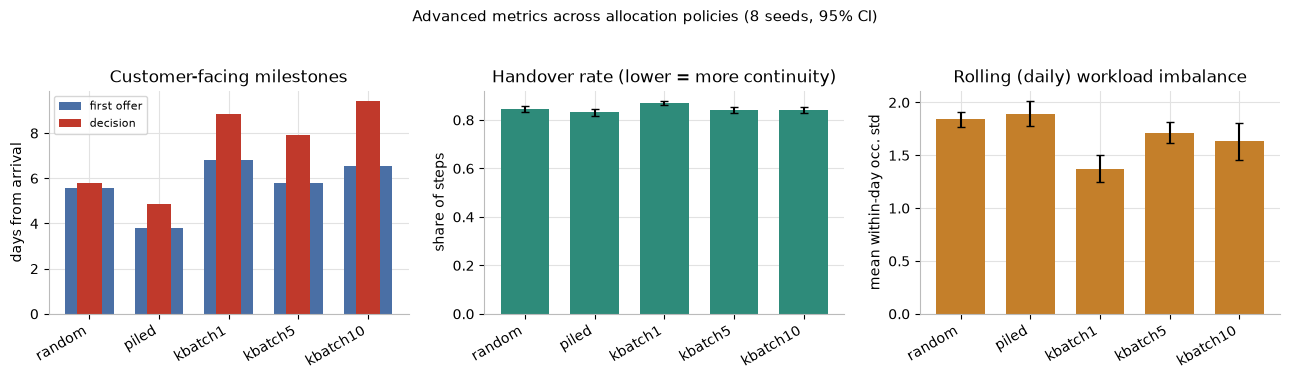

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
x = np.arange(len(POLICIES))

ax[0].bar(x, adv["time_to_first_offer_d"], color=BLUE, width=0.7, label="first offer")
ax[0].bar(x, adv["time_to_decision_d"], color=RED, width=0.35, label="decision")
ax[0].set(title="Customer-facing milestones", ylabel="days from arrival", xticks=x)
ax[0].set_xticklabels(POLICIES, rotation=30, ha="right"); ax[0].legend(fontsize=8)

ax[1].bar(x, adv["handover_rate"], yerr=adv["±hand"], color="#2e8b7a", capsize=3, width=0.7)
ax[1].set(title="Handover rate (lower = more continuity)", ylabel="share of steps", xticks=x)
ax[1].set_xticklabels(POLICIES, rotation=30, ha="right")

ax[2].bar(x, adv["rolling_balance_std"], yerr=adv["±roll"], color="#c47f2a", capsize=3, width=0.7)
ax[2].set(title="Rolling (daily) workload imbalance", ylabel="mean within-day occ. std", xticks=x)
ax[2].set_xticklabels(POLICIES, rotation=30, ha="right")

fig.suptitle("Advanced metrics across allocation policies (8 seeds, 95% CI)", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

**What the advanced metrics add.**

- **Milestone metrics quantify `piled`'s advantage where the customer actually feels it.** `piled` gets an applicant a first offer in **3.8 d vs 5.6 d** for `random`, and to a *decision* in 4.9 d vs 5.8 d. Cycle time already favoured `piled` (Section 2), but these say *why it matters to a person*: the wait for the first sign of life is a third shorter. And they are defined for cases still in flight, which a completed-only cycle-time average silently drops — on a loan process "when will I hear back?" is a more honest service KPI than a back-office cycle time.
- **Handover rate moves in Piled Execution's intended direction, but only slightly** (0.831 vs 0.846 for `random`; CI ±0.014, so the gap is real but small). Piled's mechanism is to keep the next same-activity instance with the same resource, which should lower handovers — and it does. The effect is modest because most consecutive steps in a loan case are *different* activities, so there is limited same-activity work to keep together. Reporting the small honest number is the point: the metric confirms the mechanism without overselling it, where a splashier claim would not survive the CI.
- **Rolling (daily) imbalance among human staff is far larger than whole-horizon fairness** (≈1.4–1.9 here vs 0.9–1.1 in Section 2) — the single-number fairness metric averages bursts away. Tellingly, batching has the *lowest* daily imbalance (`kbatch1` at 1.37) even though it was the *worst* policy on cycle time: the per-batch optimal assignment spreads each batch evenly, which whole-horizon fairness couldn't see and cycle time actively disagrees with. Yet another metric nominating a different winner (Decision 1).

> **Decision 3 — keep a metric only if it can *disagree* with the ones you already have.** Milestones report on in-flight cases cycle time drops; rolling balance contradicts whole-horizon fairness *and* ranks batching best (opposite to cycle time); handover confirms a mechanism the aggregates can't localise. A metric that merely restates cycle time was not added — each of the four earns its place by measuring something the three aggregate metrics structurally cannot.

---

## 4. Management question — *"Fire two employees. Which two?"*

We answer the firing question (rather than the nine-to-five one) because the simulator already has the exact lever it needs: `run_once(..., excluded_override=...)` removes a *fixed* set of resources and re-runs everything else identically — a clean **leave-N-out** experiment under CRN. (The nine-to-five variant would instead reshape the §1.6 availability windows; we note at the end why the firing question is the sharper one to demonstrate here.)

**Candidates are human staff only.** You cannot fire the automation. Per the preliminary above, `User_1` is an automated account (Johannes §1.6), so it is excluded from the candidate pool — leaving the **16 humans**. The wrong way to answer among them is "fire whoever looks least busy." We show that the *right* selection is a **criticality ranking**.

### 4.1 How we select — criticality, not just occupation

A human is *safe to fire* when removing them barely moves the metrics. Three signals predict that, and they must be combined:

1. **Occupation** — low occupation means spare capacity that others can absorb. (Naive answer stops here.)
2. **Exclusive permissions** — activities that *only this person* is allowed to perform (§1.7). Firing such a person makes those activities un-runnable: a single point of failure. This is a hard veto, and occupation can miss it — a sole owner can sit at middling occupation and still be irreplaceable. Among the 16 humans exactly one qualifies: `User_5`, the sole owner of `W_Personal Loan collection`. (The other activity with a single owner, `A_Submitted`, belongs to the automation, so it is not a human firing risk.)
3. **Throughput share** — the fraction of executed activity instances the person actually did. A low share means little work to redistribute.

In [8]:
# --- Signal 2: exclusive permissions -- activities a resource is the SOLE
#     permitted owner of. Computed over ALL resources so that an activity only
#     the automation can do (A_Submitted -> User_1) is correctly NOT credited to
#     any human; among humans only User_5 is a sole owner (W_Personal Loan
#     collection). We then keep human staff only as fire candidates.
who_can = {}
for res, acts in RESOURCE_PERMISSIONS.items():
    for a in acts:
        who_can.setdefault(a, set()).add(res)
exclusive_count = {r: 0 for r in RESOURCE_PERMISSIONS}
for a, holders in who_can.items():
    if len(holders) == 1:
        exclusive_count[next(iter(holders))] += 1

# --- Signals 1 & 3: occupation + throughput share, HUMAN staff only ---
# occupation per_resource is already human-only (evaluate got resource_subset=HUMANS).
occ_by_res = pd.DataFrame([m["occupation"]["per_resource"] for m in results["random"]]).mean()

share_frames = []
for m in results["random"]:
    inst = om.paired_instances(m["_df"])
    inst = inst[inst["resource"].isin(HUMANS)]      # human staff only
    share_frames.append(inst["resource"].value_counts(normalize=True))
throughput_share = pd.concat(share_frames, axis=1).mean(axis=1).fillna(0.0)

crit = pd.DataFrame({
    "occupation": occ_by_res,
    "throughput_share": throughput_share,
    "exclusive_perms": pd.Series(exclusive_count),
    "perm_breadth": pd.Series({r: len(a) for r, a in RESOURCE_PERMISSIONS.items()}),
}).reindex(sorted(HUMANS)).fillna(0.0)               # candidates = human staff only

# Composite criticality: high occupation OR any exclusive permission OR high throughput = critical.
# Normalise the two continuous signals to [0,1]; exclusive perms is a hard flag worth a full point each.
def _norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
crit["criticality"] = (_norm(crit["occupation"]) + _norm(crit["throughput_share"])
                       + crit["exclusive_perms"])
crit = crit.sort_values("criticality")
crit.round(3)

,occupation,throughput_share,exclusive_perms,perm_breadth,criticality
User_113,3.422,0.015,0,12,0.004
User_123,4.611,0.015,0,10,0.459
User_75,3.882,0.069,0,23,0.839
User_68,4.540,0.060,0,22,0.980
User_121,4.053,0.077,0,12,1.010
User_30,5.191,0.049,0,23,1.104
User_116,4.583,0.071,0,11,1.137
User_29,4.586,0.072,0,22,1.152
User_118,5.386,0.049,0,14,1.174
User_3,4.267,0.091,0,19,1.257


**Reading the ranking (16 humans, least- to most-critical).**

- The **top rows** are the fire candidates: `User_113` (criticality 0.004) and `User_123` (0.459) — low occupation, tiny throughput share, **zero exclusive permissions**.
- The **bottom row is `User_5` (criticality 2.337)**, and it is instructive *why*. On occupation alone (4.96) `User_5` is mid-pack — utterly unremarkable, nowhere near a fire candidate but nowhere near an obvious "keep at all costs" either. What makes it the single most critical human is the **exclusive-permission veto**: `User_5` is the *only* person who can perform `W_Personal Loan collection`, so removing it makes that activity impossible and every case that needs it stalls. Occupation cannot see that; the veto can.

That is the point of combining signals rather than sorting on occupation. "Least busy" and "least critical" happen to agree at the *top* of this ranking (our safe picks are genuinely idle *and* harmless), but they diverge exactly where it is dangerous — a middling-occupation person can be a single point of failure. So we select the two least-critical humans, `User_113` and `User_123`, and in §4.2 we deliberately contrast that against firing the exclusive holder `User_5` to show what the criticality veto is protecting against.

In [9]:
fire_safe = list(crit.index[:2])   # our pick: two least-critical human staff

# The instructive contrast: swap the second least-critical pick for the one
# human who holds an exclusive permission (User_5, sole owner of W_Personal
# Loan collection). This isolates "harmless extra person" vs "single point of
# failure" against the same first pick.
excl_humans = list(crit[crit["exclusive_perms"] > 0].index)
fire_risky = [excl_humans[0], fire_safe[0]] if excl_humans else list(crit.index[-2:])

print("Least-critical pick   :", fire_safe,
      "-> exclusive perms:", [int(crit.loc[r, "exclusive_perms"]) for r in fire_safe])
print("Exclusive-holder pick :", fire_risky,
      "-> exclusive perms:", [int(crit.loc[r, "exclusive_perms"]) for r in fire_risky])

Least-critical pick   : ['User_113', 'User_123'] -> exclusive perms: [0, 0]
Exclusive-holder pick : ['User_5', 'User_113'] -> exclusive perms: [1, 0]


### 4.2 Impact on the metrics — leave-2-out simulation

We re-run the full pipeline three times under identical seeds and horizon: **baseline** (nobody fired), **our pick** (the two least-critical humans removed), and the **exclusive-holder contrast** (`User_5` plus the same first pick `User_113`, so the only difference from our pick is swapping the harmless `User_123` for the single-point-of-failure `User_5`). Because CRN fixes arrivals and durations, any metric difference is caused *only* by the missing staff. Occupation and fairness are measured over the **surviving** humans in each scenario.

In [10]:
def summarise(ms):
    ct   = [m["cycle_time"]["avg_cycle_time_s"] / DAY for m in ms]
    occ  = [m["occupation"]["avg_resource_occupation"] for m in ms]
    fair = [m["fairness"]["resource_fairness"] for m in ms]
    comp = [m["case_filter"]["n_cases_completed"] for m in ms]
    tdec = [m["custom_metrics"]["time_to_decision"]["mean_s"] / DAY for m in ms]
    return {
        "cycle_time_d": np.mean(ct), "±ct": ci95(ct),
        "occupation": np.mean(occ),
        "fairness": np.mean(fair),
        "time_to_decision_d": np.nanmean(tdec),
        "n_completed": np.mean(comp),
    }

# For each firing scenario, resource-centric metrics are taken over the
# SURVIVING humans (HUMANS minus the fired staff), so a fired person does not
# linger as a zero-occupation "unfairly idle" entry.
scenarios = {
    "baseline (fire nobody)":
        run_policy("random", excluded=set(), subset=HUMANS),
    f"fire 2 least-critical {fire_safe}":
        run_policy("random", excluded=set(fire_safe), subset=HUMANS - set(fire_safe)),
    f"fire incl. exclusive-holder {fire_risky}":
        run_policy("random", excluded=set(fire_risky), subset=HUMANS - set(fire_risky)),
}
fire_tbl = pd.DataFrame({k: summarise(v) for k, v in scenarios.items()}).T
fire_tbl.round(3)

[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 40939, Cases started: 1807, Cases completed: 436, Wall time: 4.971s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 44585, Cases started: 1939, Cases completed: 529, Wall time: 4.825s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 40673, Cases started: 1819, Cases completed: 415, Wall time: 4.794s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 40978, Cases started: 1648, Cases completed: 490, Wall time: 4.064s
[Engine] Starting simulation (duration=1814400s)


...

[Engine] Simulation complete. Events processed: 39914, Cases started: 1902, Cases completed: 440, Wall time: 5.203s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 39393, Cases started: 1599, Cases completed: 429, Wall time: 4.816s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 42125, Cases started: 1761, Cases completed: 456, Wall time: 5.172s
[Engine] Starting simulation (duration=1814400s)


[Engine] Simulation complete. Events processed: 39159, Cases started: 1725, Cases completed: 402, Wall time: 5.460s


,cycle_time_d,±ct,occupation,fairness,time_to_decision_d,n_completed
baseline (fire nobody),5.596,0.287,4.774,1.008,5.796,483.000
"fire 2 least-critical ['User_113', 'User_123']",5.927,0.272,4.943,0.898,6.797,431.375
"fire incl. exclusive-holder ['User_5', 'User_113']",5.525,0.310,4.857,0.947,6.975,422.875


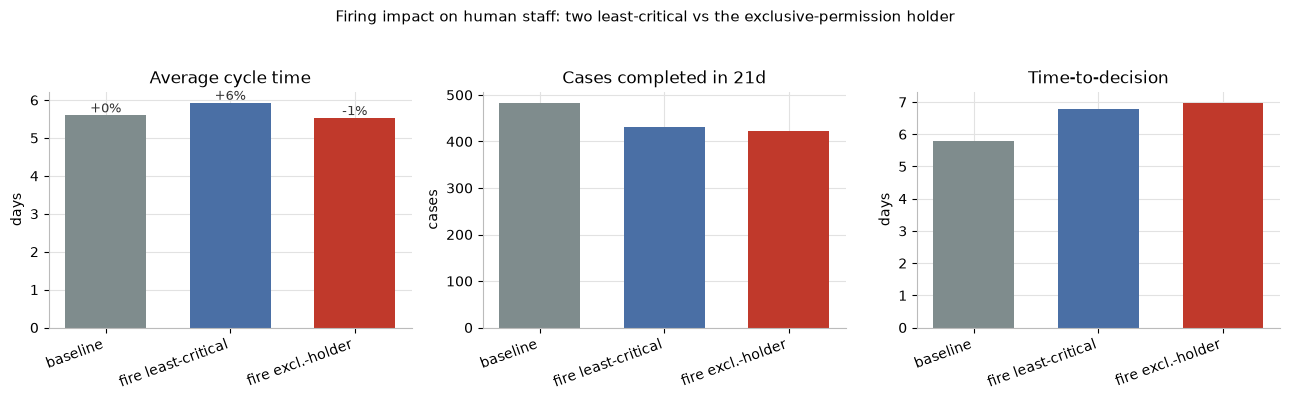

In [11]:
base = fire_tbl.loc["baseline (fire nobody)"]
labels = list(fire_tbl.index)
short = ["baseline", "fire least-critical", "fire excl.-holder"]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
x = np.arange(len(labels))
cols = [GREY, BLUE, RED]

for a, col, title, unit in [
    (ax[0], "cycle_time_d", "Average cycle time", "days"),
    (ax[1], "n_completed", "Cases completed in 21d", "cases"),
    (ax[2], "time_to_decision_d", "Time-to-decision", "days"),
]:
    a.bar(x, fire_tbl[col], color=cols, width=0.65)
    a.set(title=title, ylabel=unit, xticks=x)
    a.set_xticklabels(short, rotation=20, ha="right")

# annotate % change vs baseline on cycle time
for i, lab in enumerate(labels):
    d = 100 * (fire_tbl.loc[lab, "cycle_time_d"] - base["cycle_time_d"]) / base["cycle_time_d"]
    ax[0].text(i, fire_tbl.loc[lab, "cycle_time_d"], f"{d:+.0f}%", ha="center",
               va="bottom", fontsize=9, color="#333")

fig.suptitle("Firing impact on human staff: two least-critical vs the exclusive-permission holder",
             y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

**The impact — and the trap the selection method avoids.**

- **Firing the two least-critical humans has a real but bounded cost.** Cycle time rises 5.60 → 5.93 d (**+6%**), completions fall 483 → 431 (**−11%**), and time-to-decision 5.80 → 6.80 d (**+17%**). The survivors just absorb the freed work: their occupation rises (4.77 → 4.94) and fairness even improves slightly (1.01 → 0.90), because the two we removed were low-load outliers. This is the honest answer to management: *fire `User_113` and `User_123`; here is the measured cost — a few percent slower and about a tenth fewer cases cleared — bounded and defensible.*
- **The exclusive-holder cut looks *better* on cycle time and is worse for the business.** Firing `User_5` (with `User_113`) gives the **lowest cycle time of all three scenarios — 5.53 d, even below the baseline** — so a manager optimising the headline number would *prefer* this cut to firing the two harmless people (5.93 d). It is a **mirage**: at the same time completions fall furthest (483 → 423, **−12%**) and time-to-decision is the worst of the three (5.80 → 6.98 d, **+20%**). Cycle time is measured on *completed* cases only (Section 1), so once `User_5`'s exclusive `W_Personal Loan collection` can no longer be performed, the cases that need it stall and never finish — they **leave the average instead of dragging it up**. The apparent improvement is survivorship, not service.
- **This is Decision 1 with a job on the line.** Cycle time alone would rank firing the single point of failure as the *best* cut; completions, time-to-decision, and the exclusive-permission veto all say it is the *worst*. The criticality ranking encodes that veto up front, so it never proposes the tempting-but-wrong cut in the first place.

> **Decision 4 — select by a criticality ranking (throughput × occupation × a *hard* exclusive-permission veto) over human staff, then price the cut with a leave-2-out CRN simulation, reading completions and time-to-decision *alongside* cycle time.** Firing the two least-critical humans costs ≈6% cycle time and ≈11% completions here; firing the exclusive-permission holder `User_5` would look *better* on cycle time precisely because it makes the cases that need its unique activity silently fail to complete — the exact outcome the veto exists to prevent.

### A note on the alternative question (nine-to-five)

The other management question — *"reduce working hours to nine-to-five"* — is answerable with the same machinery from the opposite direction: instead of `excluded_override` it would **reshape the §1.6 availability windows** (clamp every human's daily window to 09:00–17:00, and optionally prescribe attendance every weekday). Given what we just saw, the expected metric story is the mirror of firing: occupation *up* (less availability, same demand), cycle time and time-to-decision *up*, and rolling daily imbalance likely *worse* as work concentrates into a narrower window. We demonstrated the firing question because the leave-N-out lever already exists and yields a cleanly paired experiment; the nine-to-five variant is a focused edit to `analysis/availability.py` (a per-weekday window clamp) rather than a re-derivation, and would reuse every metric in this notebook unchanged.

---

## Summary of design decisions

| # | Decision | Why it matters |
|---|---|---|
| 0 | **Count only human staff as resources for staffing metrics.** `User_1` has no §1.6 working calendar → it is automation (Johannes, Decision 4), excluded data-drivenly from occupation, fairness, rolling balance, and the fire pool | Including an always-on robot with a huge availability denominator distorts every per-person metric and would let the analysis "fire" infrastructure. Process-level metrics keep every case — the automation really does that work. |
| 1 | **Never rank policies (or firing choices) on a single metric** — read cycle time, occupation *and* completions together | At this horizon batching has the fewest completions, the highest cycle time *and* the lowest occupation at once; three metrics, three different "winners". The firing experiment shows the same trap with a job attached. |
| 2 | Read **fairness as a diagnostic of the permission model (§1.7)**, not of the allocation policy | An allocation rule only redistributes work among *permitted* resources; each person's reachable load is capped by their permissions, so fairness moves only modestly (0.92–1.13) with no consistent policy ordering. The fairness lever is §1.7. |
| 3 | A metric earns its place only if it can **disagree** with the ones you already have | Milestone metrics report on in-flight cases cycle time drops; rolling daily balance contradicts whole-horizon fairness *and* ranks batching best; handover confirms Piled Execution's mechanism (small but real, 0.831 vs 0.846). |
| 4 | Fire by a **criticality ranking** (throughput × occupation × a hard exclusive-permission veto) over human staff, then price the cut with a **leave-2-out CRN simulation** | "Least busy" ≠ "least critical": `User_5` sits at middling occupation yet is the sole owner of a mandatory activity — firing it *flatters* cycle time via survivorship (its cases never complete) while completions and time-to-decision worsen. The veto blocks that cut; the ranking picks the genuinely safe two (`User_113`, `User_123`) at ≈6% cycle time / ≈11% completions cost. |

**Experimental settings (restated).** 21-day horizon from 2016-01-01, seeds 1–8, Common Random Numbers on (paired comparisons), cycle time on completed cases only, occupation relative to the §1.6 availability windows and computed over the 16 human staff. Policies: `random` (R-RMA), `piled` (R-PE), `kbatch{1,5,10}` (k-Batching). All numbers reproduce from `scripts/run_experiments.run_once` + `scripts/opt_metrics.evaluate(..., resource_subset=HUMANS)`; the leave-N-out lever is the `excluded_override=` argument on `run_once`.